# Лекция 5. Метод Ньютона, квази-ньютоновские методы и Гаусс–Ньютон: локальная сходимость

**Курс:** Вычислительная оптимизация · **Часть II. Безусловная оптимизация и ньютоновские методы** · Лекция 5 из 16 · 7 октября 2026

**Материалы:** [конспект-ноутбук с кодом демонстраций](lecture05.ipynb) · [демо-ноутбук](demo05.ipynb) · [семинар: свой Ньютон и BFGS против SciPy](seminar05.ipynb) · [разбор упражнений](exercises05.ipynb) · [сценарий доски](board05.md)

В конспекте-ноутбуке две демонстрации стоят прямо в тексте: «Демо (a)» — Ньютон и демпфирование на Розенброке — после раздела 3, «Демо (b)» — BFGS — после раздела 4. Задачи-крючки, Гаусс–Ньютон на синусе и биография цепи — только в `demo05.ipynb` (части (0), (c), (d)).

---

Лекция 4 закончилась обещанием: градиентный спуск сходится линейно и платит за каждую верную цифру $\sim\kappa$ итераций, а один тизер — метод Ньютона — прошёл Розенброка за $7$ итераций вместо $13\,756$. Сегодня разбираемся, за счёт чего и какой ценой. Три вопроса:

1. Почему Ньютон делает за $7$ шагов то, на что спуску нужно $13\,756$, — и почему при этом его второй шаг улетает в $(0.76,\,-3.18)$?
2. Гессиан — это $n^2$ производных и решение системы $n\times n$ на каждом шаге. Можно ли обойтись без него — *измерить* кривизну по градиентам, которые мы и так считаем?
3. У задач подгонки — сумм квадратов невязок — есть структура. Даёт ли она «почти Ньютона» за цену одного градиента?

Все методы сегодня — **одна формула**:

$$
\boxed{\;x_{k+1}=x_k-\alpha_k\,B_k^{-1}\,\nabla f(x_k)\;}
$$

Матрица $B_k$ — это то, что метод *знает о кривизне* функции в точке $x_k$; $\alpha_k$ — длина шага. Градиентный спуск ничего о кривизне не знает: $B_k=I$. Лекция заполняет три строки таблицы ниже, по одной на раздел, и каждый ответ — выбор $B_k$. Все они — один и тот же рецепт Ньютона «линеаризуй и реши» в разной обстановке: для уравнения $F(x)=0$ — с якобианом, для минимума — с гессианом (потому что минимум — это уравнение $\nabla f=0$), для суммы квадратов — с $J^\top J$ вместо гессиана, а Левенберг–Марквардт и BFGS — тот же шаг с «починенной» или «выученной» матрицей. Второй сюжет лекции — что происходит, когда кривизна, которую метод *думает*, что знает, врёт.

| Метод | $B_k$ | Что нужно от $f$ | Цена шага | Сходимость | Розенброк из $(-1.2,1)$ |
|---|---|---|---|---|---|
| градиентный спуск (Л4) | $I$ | $\nabla f$ | $O(n)$ | линейная, $\propto\kappa$ | $13\,756$ |
| Ньютон (раздел 2–3) | ? | ? | ? | ? | $7$ |
| BFGS (раздел 4) | ? | ? | ? | ? | ? |
| Гаусс–Ньютон (раздел 5) | ? | ? | ? | ? | синус: ? |

> **Код в этом ноутбуке.** Две демонстрации из [`demo05.ipynb`](demo05.ipynb) вставлены в те разделы, к которым относятся: «Демо (a)» — Ньютон и демпфирование — после раздела 3, «Демо (b)» — BFGS — после раздела 4; остальные части (задачи, Гаусс–Ньютон, цепь) — только в `demo05.ipynb`. При чтении демо можно пропускать, на лекции — запускать по ходу. Вспомогательный код (палитра, методы `gd`, `newton`, `newton_damped`, `bfgs`, `gauss_newton`, задачи и рисовальщики) вынесен в [`l5helpers.py`](l5helpers.py); его подключает ячейка ниже.

In [1]:
%matplotlib inline

from l5helpers import *  # палитра, методы, задачи, рисовальщики (см. файл рядом)

## 1. Повторение и мост: от линейной модели к квадратичной

### 1.1. Что уже умеем

| Вопрос | Ответ | Где |
|---|---|---|
| Как узнать минимум? | $\nabla f(x^\ast)=0$ необходимо; $\nabla^2f(x^\ast)\succ0$ — достаточно для строгого локального минимума; седло тоже стационарно | Л4, §2–3 |
| Куда шагать и на сколько? | против градиента; шаг $\alpha<2/L$ безопасен; backtracking — пробуем $\alpha=1$ и делим пополам, пока $f$ не уменьшится | Л4, §4 |
| Сколько итераций? | $\approx\kappa\ln(1/\varepsilon)$ — линейная сходимость с множителем $1-1/\kappa$; Розенброк $\kappa=2508$, цепь $N=40$ — $\kappa=681$ | Л4, §5 |
| Какие бывают скорости? | линейная — прямая на графике $\log\lVert e_k\rVert$; сверхлинейная — всё круче; квадратичная — $\lVert e_{k+1}\rVert\le C\lVert e_k\rVert^2$, на графике обрыв | Л4, §6 |

**Обозначения на всю лекцию.** $g_k=\nabla f(x_k)$ — градиент в текущей точке, $\nabla^2f(x_k)$ — гессиан (симметричная матрица $n\times n$; в коде ДЗ 3 он обозначен `H`), $e_k=x_k-x^\ast$ — ошибка, $p$ — **смещение** из текущей точки: следующая точка — $x_k+p$. $B_k$ — матрица кривизны в формуле лекции.

### 1.2. Две задачи на сегодня

<img src="img/00_hooks.png" width="900" alt="две задачи: Розенброк с путями спуска и Ньютона; подгонка синуса из ДЗ 2 — данные, кривая спуска и кривая Ньютона с нулевой амплитудой">

**Розенброк** (Л4, §1.2), старт $(-1.2,\,1)$. Спуск с backtracking — $13\,756$ итераций, Ньютон — $7$. Но посмотрите на путь Ньютона: вторая итерация уводит в $(0.76,\,-3.18)$, ошибка *растёт* вдвое, и лишь с четвёртого шага начинается обрыв. К концу раздела 3 мы будем знать, почему оба факта — и $7$, и выброс — следствия одной формулы.

**Подгонка синуса** (ДЗ 2, задача 2(б)). Те же $60$ измерений $y_i=2\sin(3t_i+0.7)+\varepsilon_i$ и та же модель $\varphi(t;x)=x_1\sin(x_2t+x_3)$. Это **нелинейный МНК**: $f(x)=\tfrac12\sum_i r_i(x)^2$, $r_i=\varphi(t_i;x)-y_i$. Из старта $(1,\,3,\,0)$ градиентный спуск доползает до $f^\ast=1.1393$ за $731$ итерацию, а чистый метод Ньютона сходится за $9$ итераций — в точку с $x_1=0$, к модели «ноль», которая не описывает данные вовсе. Ньютон не ошибся: он честно нашёл стационарную точку. Не ту. Метод раздела 5, который пользуется структурой суммы квадратов, доходит до правильного ответа за $7$ итераций.

Третья задача — **цепь без пола** ($N=40$ грузов, $80$ переменных, выпуклая квадратичная энергия; Л1 §7.3, Л4 §1.2) — будет мерилом в разделе 6: на ней каждый метод лекции получает своё число итераций.

### 1.3. Что сегодня

Ньютон для уравнений и для оптимизации — «линеаризуй и реши», квадратичная модель (раздел 2) → квадратичная сходимость и её граница: куда приходит Ньютон, демпфирование, седловая модель (3) → секущее уравнение и построение BFGS (4) → Ньютон для суммы квадратов: Гаусс–Ньютон и Левенберг–Марквардт (5) → заполненная таблица и биография цепи (6). Семинар — за ноутбуком: пишем Ньютона и BFGS сами и сравниваем со SciPy (раздел 10).

## 2. Метод Ньютона: линеаризуй и реши

### 2.1. Ньютон для уравнений

Начнём не с минимума, а с уравнения. Пусть надо решить $F(x)=0$, $F:\mathbb R\to\mathbb R$. В текущей точке $x_k$ заменим $F$ касательной — линейной моделью по Тейлору: $F(x_k+\Delta)\approx F(x_k)+F'(x_k)\,\Delta$. Приравняем модель к нулю и найдём $\Delta$:

$$
F(x_k)+F'(x_k)\,\Delta=0\quad\Longrightarrow\quad \Delta_k=-\frac{F(x_k)}{F'(x_k)},\qquad x_{k+1}=x_k+\Delta_k .
$$

Геометрически — шаг в точку, где касательная пересекает ось $x$. Это **метод Ньютона для уравнений**, и весь его рецепт — *линеаризуй и реши линейную задачу*. Вблизи простого корня ($F'(x^\ast)\ne0$) ошибка возводится в квадрат: $|x_{k+1}-x^\ast|\le C\,|x_k-x^\ast|^2$ — из ошибки $10^{-2}$ следующий шаг делает $\sim10^{-4}$, ещё один — $\sim10^{-8}$ (упражнение 11.0(б): для $\sqrt2$ ошибки $0.086,\ 0.0025,\ 2.1\cdot10^{-6}$; доказательство — в §3.1). Проблемы тоже видны из формулы: плохой старт, $F'(x_k)\approx0$ — касательная почти горизонтальна и шаг огромен, слишком большие шаги вообще.

В $n$ измерениях то же самое. Для $F:\mathbb R^n\to\mathbb R^n$ роль производной играет **матрица Якоби** $J_F$, $(J_F)_{ij}=\partial F_i/\partial x_j$:

$$
F(x_k+p)\approx F(x_k)+J_F(x_k)\,p=0\quad\Longrightarrow\quad J_F(x_k)\,p_k=-F(x_k),\qquad x_{k+1}=x_k+p_k .
$$

Здесь $p$ — смещение из текущей точки, вектор той же размерности, что $x$. На каждом шаге нужны якобиан и решение линейной системы $n\times n$; если $J_F(x^\ast)$ невырожден и старт близок, сходимость снова квадратичная.

### 2.2. Ньютон для оптимизации: уравнение $\nabla f=0$ и квадратичная модель

Минимум — стационарная точка: $\nabla f(x)=0$. Это система $n$ уравнений с $n$ неизвестными, $F=\nabla f$, и её якобиан — гессиан: $J_F=\nabla^2f$. Подставляем в формулу §2.1:

$$
\boxed{\;\nabla^2f(x_k)\,p_k=-g_k,\qquad x_{k+1}=x_k+p_k\;}
$$

Это **метод Ньютона для оптимизации**: Ньютон, применённый к уравнению $\nabla f=0$. В формуле лекции $B_k=\nabla^2f(x_k)$ и $\alpha_k=1$.

**Второй вывод — через квадратичную модель.** Тот же шаг получается, если линеаризовать не градиент, а саму функцию — до второго порядка. Заменим $f$ в окрестности $x_k$ разложением Тейлора по смещению $p$ — **квадратичной моделью**:

$$
m_k(p)=f(x_k)+g_k^\top p+\tfrac12\,p^\top\nabla^2f(x_k)\,p .
$$

Три слагаемых — три вещи, которые модель знает о функции в точке $x_k$: её **высоту** $f(x_k)$, её **наклон** $g_k$ и её **кривизну** $\nabla^2f(x_k)$. При $p=0$ модель совпадает с функцией; при малых $p$ ошибка модели есть $o(\lVert p\rVert^2)$. В одной переменной модель — парабола, которая в точке $x_k$ проходит через график, имеет тот же наклон и изгибается так же, как он.

<img src="img/01_model_1d.png" width="900" alt="функция одной переменной и касательная парабола в точке x_k: та же высота, наклон и кривизна; вершина параболы — следующая точка">

Градиентный спуск пользовался только первыми двумя слагаемыми. Линейная модель минимума не имеет, поэтому длину шага $\alpha$ пришлось назначать снаружи. Квадратичная модель — другое дело: если $\nabla^2f(x_k)\succ0$, это чаша с единственным минимумом, и его можно взять за следующую точку. Градиент модели по $p$ равен нулю, $\nabla m_k(p)=g_k+\nabla^2f(x_k)\,p=0$, — та же система, что выше. Длина шага *не выбирается*: вершина параболы сама говорит, куда и на сколько. На квадратичной функции модель совпадает с функцией, и минимум находится за один шаг — именно так в лекции 4 цепь решалась одним `np.linalg.solve`.

<img src="img/02_model_ellipses.png" width="900" alt="Розенброк: линии уровня функции и эллипсы квадратичной модели в стартовой точке и во второй итерации Ньютона">

Серые линии — уровни $f$ на Розенброке, оранжевые — уровни модели $m_k$ в двух точках пути Ньютона; квадрат — минимум модели, он же следующая точка. В старте модель похожа на функцию, и шаг разумный. В точке $x_1$ модель — вытянутый эллипс, её минимум $(0.76,-3.18)$ лежит далеко от всего, что похоже на функцию, и $f$ там *больше*, чем в $x_1$. **Ньютон ошибается ровно там, где врёт модель.**

**Два следствия.** Первое: метод решает $\nabla f=0$, а нуль градиента — это и минимум, и максимум, и седло; чашу от перевала он не отличает. Отсюда синус из крючка: точка с $x_1=0$ — стационарная, и Ньютон ею вполне доволен. Второе: координаты методу безразличны. Замена переменных $x=Au$ с невырожденной $A$ переводит $f$ в $\tilde f(u)=f(Au)$; шаг Ньютона в новых координатах — это ровно тот же шаг $p$, пересчитанный в них: $A\tilde p=p$ (вывод — упражнение 11.1(б)). Путь итераций один и тот же, в каких бы единицах ни измерялись переменные. У градиентного спуска всё наоборот: замена $u_2=5x_2$ меняла число итераций с $378$ на $1$ (Л4, §5.4). Число обусловленности — свойство координат, а Ньютон координат не видит; поэтому $\kappa=2508$ Розенброка ему безразлично.

### 2.3. Одна переменная: парабола едет по функции

$f(x)=\ln\cosh x$ — гладкая чаша с минимумом в нуле, но с *убывающей* кривизной: $f''=1/\cosh^2x\to0$ на бесконечности. В точке $x_k$ модель — парабола с той же высотой, наклоном и кривизной; следующая точка — её вершина:

$$
x_{k+1}=x_k-\frac{f'(x_k)}{f''(x_k)}=x_k-\tanh x_k\cosh^2x_k=x_k-\tfrac12\sinh 2x_k .
$$

<img src="img/03_newton_1d.png" width="900" alt="ln cosh x: касательные параболы и шаги Ньютона из 0.9 (сходится) и из 1.2 (перелёт и расходимость)">

Из $x_0=0.9$ парабола стоит почти там же, где функция: ошибки $0.57,\ 0.13,\ 1.6\cdot10^{-3},\ 2.5\cdot10^{-9}$ — четыре шага, и мы на дне. Из $x_0=1.2$ кривизна в точке мала, парабола широкая, её вершина перелетает через нуль дальше, чем мы были, — и с каждым шагом дальше: $1.2\to-1.53\to3.82\to-516$. Граница между двумя исходами — старт $x_0\approx1.0886$, из которого шаг переносит ровно в $-x_0$, и метод застревает в 2-цикле.

<img src="img/15_parabola_rides.gif" width="900" alt="анимация: старт Ньютона на ln cosh x движется от 0.3 до 1.3; до порога 1.0886 парабола-модель за три шага приводит в нуль, после — вершина параболы перелетает всё дальше">

На анимации старт $x_0$ ползёт слева направо: парабола-модель становится всё шире, а её вершина — всё дальше от минимума, пока в $1.0886$ метод не перестаёт сходиться. Это и есть «модель врёт»: вторая производная в точке ничего не знает о функции вдали от неё.

**Как же так — функция выпуклая, а метод расходится?** Выпуклость гарантирует $f''>0$, то есть *направление* шага: $-f'/f''$ всегда смотрит в сторону минимума. Но о *длине* шага выпуклость не говорит ничего — длину назначает парабола, а парабола знает кривизну только в точке $x_k$. У $\ln\cosh$ кривизна $1/\cosh^2x$ убывает к нулю: вдали от нуля функция почти прямая ($f'\to\pm1$), парабола с крошечной кривизной очень широкая, и её вершина далеко — шаг $\tfrac12\sinh2x_k$ растёт экспоненциально по $|x_k|$. Для сравнения: градиентному спуску с шагом $\alpha\le1$ здесь ничего не грозит — $|f'|\le1$, и каждый его шаг не длиннее единицы. Ньютон быстрее именно потому, что верит модели; на той же вере он и ломается. В §3.1 это будет видно в формуле: ошибка возводится в квадрат, а квадрат числа больше единицы *больше* самого числа. Лечение — в §3.4: если шаг не уменьшил $f$, укоротить его; из $x_0=5$ такой метод сходится (упражнение 11.3(г)).

**Одной строкой.** Ньютон — «линеаризуй и реши»: для уравнения $F=0$ — с якобианом, для минимума — с гессианом, потому что $F=\nabla f$; тот же шаг — минимум квадратичной модели; длину шага задаёт модель, координат метод не замечает, но верит модели и там, где она врёт: выпуклость гарантирует направление шага, а не его длину.

## 3. Локальная сходимость: обрыв и его граница

### 3.1. Теорема: ошибка возводится в квадрат

Начнём с одной переменной — здесь всё доказательство укладывается в три строки. Пусть $f'(x^\ast)=0$, $f''>0$ вблизи $x^\ast$, $e_k=x_k-x^\ast$. Разложим *производную* $f'$ по Тейлору в точке $x_k$ и подставим $x^\ast=x_k-e_k$:

$$
0=f'(x^\ast)=f'(x_k)-f''(x_k)\,e_k+\tfrac12f'''(\xi)\,e_k^2
$$

для некоторого $\xi$ между $x_k$ и $x^\ast$. Разделим на $f''(x_k)$ и перенесём: $\dfrac{f'(x_k)}{f''(x_k)}=e_k-\dfrac{f'''(\xi)}{2f''(x_k)}\,e_k^2$. А шаг Ньютона вычитает из $x_k$ ровно $f'(x_k)/f''(x_k)$, поэтому

$$
e_{k+1}=e_k-\frac{f'(x_k)}{f''(x_k)}=\frac{f'''(\xi)}{2f''(x_k)}\;e_k^2 .
$$

Вот и всё: **новая ошибка — квадрат старой**, умноженный на отношение «как быстро меняется кривизна» к «какова кривизна». Если вблизи минимума $|f'''|\le M$ и $f''\ge m>0$, то $|e_{k+1}|\le\frac{M}{2m}\,e_k^2$.

Прочитаем доказательство словами. Шаг Ньютона отвечает на вопрос «где нуль у *касательной* к графику $f'$». Ошибка этого ответа — отброшенный член Тейлора, а он квадратичен по $e_k$. Коэффициент $f'''$ измеряет, насколько касательная врёт; у квадратичной функции $f'''=0$, и метод точен за один шаг.

**Вернёмся к $\ln\cosh$ из §2.3.** Формула объясняет и порог. Множитель $C_k=\dfrac{|f'''(\xi)|}{2f''(x_k)}$ у этой функции порядка единицы: из $x_0=0.9$ получается $|e_1|/e_0^2=0.70$, из $x_0=1.2$ — $1.06$. Ошибка убывает, только когда $C_k|e_k|<1$: возвести в квадрат число меньше единицы — значит уменьшить его, больше единицы — увеличить. Выпуклость тут ни при чём: теорема локальна, и «достаточно близко» для $\ln\cosh$ означает $|x_0|$ примерно до единицы (точное значение порога $1.0886$ — упражнение 11.3(а)).

**Теорема (в $n$ измерениях).** Пусть $\nabla f(x^\ast)=0$, в окрестности $x^\ast$ гессиан липшицев — $\lVert\nabla^2f(x)-\nabla^2f(y)\rVert\le M\lVert x-y\rVert$ — и $\nabla^2f(x)\succeq mI$ с $m>0$. Тогда для итераций Ньютона, начатых достаточно близко к $x^\ast$,

$$
\boxed{\;\lVert e_{k+1}\rVert\le\frac{M}{2m}\,\lVert e_k\rVert^2\;}
$$

Доказательство повторяет одномерное: роль $f'''$ играет липшицева константа $M$ (гессиан меняется не быстрее, чем линейно), роль $f''\ge m$ — нижняя граница собственных чисел гессиана (упражнение 11.2).

### 3.2. Что видно: обрыв на графике ошибки

Запишем оценку в логарифмах: $\log_{10}\lVert e_{k+1}\rVert\le2\log_{10}\lVert e_k\rVert+\log_{10}C$. Показатель степени ошибки на каждом шаге удваивается (с поправкой на постоянную $\log_{10}C$): $10^{-1}\to10^{-2}\to10^{-4}\to10^{-8}$. Если $C\lVert e_0\rVert<1$ при $C=M/2m$, то $C\lVert e_k\rVert\le(C\lVert e_0\rVert)^{2^k}$. На графике $\log\lVert e_k\rVert$ от $k$ линейная сходимость — прямая, квадратичная — обрыв. Розенброк из $(-1.2,1)$:

| $k$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|---|
| $\lVert e_k\rVert$ | $2.2$ | $2.21$ | $4.18$ | $0.48$ | $0.056$ | $9.6\cdot10^{-6}$ | $1.9\cdot10^{-11}$ |
| $\log_{10}\lVert e_k\rVert$ | $0.34$ | $0.34$ | $0.62$ | $-0.32$ | $-1.25$ | $-5.02$ | $-10.73$ |

Три фазы. Итерации 0–2: ошибка не убывает — модель врёт, это выброс из крючка. Итерации 3–4: ошибка меньше единицы и начинает падать. С пятой — обрыв: показатель $-1.25\to-5.0\to-10.7$, каждый раз примерно вдвое.

<img src="img/04_rates_newton.png" width="900" alt="Розенброк из (-1.2, 1): логарифм ошибки по итерациям для градиентного спуска (прямая) и чистого метода Ньютона (горб и обрыв)">

Это главный диагностический рисунок части II: спуск — прямая (линейная сходимость, $13\,756$ итераций), Ньютон — $7$ итераций с горбом в начале и обрывом в конце. Теорема описывает *тип* сходимости, а не область: для Розенброка оценка $M/2m$ гарантирует сходимость лишь из шара радиуса $3\cdot10^{-4}$ вокруг минимума (упражнение 11.2), а метод сошёлся с расстояния $2.2$.

### 3.3. Куда приходит Ньютон

Теорема обещает сходимость только из окрестности. Что снаружи? Ньютон идёт к *ближайшему в смысле модели* нулю градиента — не обязательно к минимуму и не обязательно к ближайшему геометрически.

<img src="img/05_basins.png" width="900" alt="функция Химмельблау: каждая стартовая точка сетки окрашена по тому, в какую из девяти стационарных точек пришёл чистый метод Ньютона">

Функция Химмельблау $f=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$ имеет девять стационарных точек: четыре минимума, четыре седла и один локальный максимум. Из каждой точки сетки $300\times300$ запущен чистый Ньютон; цвет — куда он пришёл. Сходится почти отовсюду, в среднем за $6$ итераций, но в минимум — только из $64\,\%$ стартов; $31\,\%$ приходят в сёдла, $4\,\%$ — в максимум, и границы областей изрезаны: соседние старты уходят в разные точки. Это цена первого следствия из §2.2: метод решает $\nabla f=0$ и не отличает чашу от перевала.

Покрутить руками — старт, метод и бассейны — можно на [интерактивной странице](https://claude.ai/artifact/9NaEBdf8cjpnMbYEdW8Zy2) (исходник — [`interactive/05_newton_vs_descent.html`](interactive/05_newton_vs_descent.html)): сцена «Бассейны» на Химмельблау и парабола из §2.3 с ползунком старта; сцена «Ньютон против спуска» на Розенброке пригодится после раздела 4.

### 3.4. Демпфирование: когда модель врёт, шаг укорачиваем

Направление Ньютона хорошее, длина — нет: вдали от минимума вершина параболы может лежать там, где модель уже не имеет отношения к функции. Разделим «куда» и «на сколько»: направление по-прежнему из модели, а длину выберем так же, как в лекции 4 выбирали для спуска:

$$
\nabla^2f(x_k)\,p_k=-g_k,\qquad x_{k+1}=x_k+\alpha_k\,p_k .
$$

**Правило Армихо** (*Armijo rule*) — это backtracking из Л4 §4.5, записанный аккуратно. Начинаем с $\alpha=1$ — с шага, который предлагает сама модель, — и делим $\alpha$ пополам, пока не выполнится

$$
f(x_k+\alpha p_k)\le f(x_k)+c\,\alpha\,g_k^\top p_k,\qquad c=10^{-4}.
$$

Справа — не просто «стало меньше», а «стало меньше хотя бы на долю $c$ от того, что обещает линейная модель»: $g_k^\top p_k<0$ — обещанное убывание на единицу длины, $\alpha\,g_k^\top p_k$ — обещание на весь шаг. Без множителя $c$ метод мог бы принимать шаги с ничтожным убыванием и ползти вечно; с $c=10^{-4}$ требование почти не строже, чем «меньше», но от этого защищает. Цикл конечен: при малых $\alpha$ истинное убывание $f$ приближается к $\alpha\,g_k^\top p_k$ — к полному обещанию, — а требуется лишь его доля $c$. Метод называют **демпфированным Ньютоном** (*damped Newton*), а саму процедуру выбора длины шага вдоль направления — **линейным поиском** (*line search*); в формуле лекции это $B_k=\nabla^2f(x_k)$ и $\alpha_k$ по Армихо.

Почему демпфирование не портит скорость: вблизи минимума модель точна, шаг $\alpha=1$ уменьшает $f$ почти на половину $|g_k^\top p_k|$, и условие с $c=10^{-4}$ выполняется с первой попытки (упражнение 11.4(в)). Укорачивание включается только там, где нужно, — вдали от минимума.

<img src="img/06_damped.png" width="900" alt="Розенброк: пути чистого и демпфированного Ньютона и логарифм ошибки; у демпфированного нет выброса, 22 итерации против 7">

На Розенброке демпфированный Ньютон делает $22$ итерации вместо $7$, зато $f$ убывает на каждом шаге, а наибольшая ошибка по пути — $2.21$ вместо $4.18$: выброса нет. Обрыв начинается позже, потому что первые шаги укорочены; в последних итерациях Армихо принимает $\alpha=1$, и метод снова чистый Ньютон.

**Когда направление — не спуск.** Правило Армихо предполагает $g_k^\top p_k<0$: что $p_k$ вообще ведёт вниз. Для шага Ньютона $g^\top p=-g^\top\big(\nabla^2f\big)^{-1}g$, и знак зависит от гессиана. Если $\nabla^2f\succ0$ — спуск гарантирован. Если же у гессиана есть отрицательное собственное число, его называют **индефинитным** (*indefinite*): квадратичная форма $p^\top\nabla^2f\,p$ принимает и положительные, и отрицательные значения, и модель — не чаша, а седло (Л4, §3). Минимума у седла нет. Уравнение $\nabla^2f\,p=-g$ по-прежнему решается, но его решение — седловая точка модели, и шаг туда может вести *вверх* по $f$.

<img src="img/07_bowl_saddle.png" width="900" alt="две квадратичные модели с одним и тем же градиентом: чаша — шаг Ньютона ведёт в её минимум, вниз; седло — шаг ведёт в седловую точку модели, вверх по функции, а регуляризованный шаг — вниз">

Лечение — то же, что для всякого плохого $B_k$: сделать матрицу положительно определённой, сдвинув все собственные числа на одно и то же $\tau$:

$$
B_k=\nabla^2f(x_k)+\tau I,\qquad \tau>\lvert\lambda_{\min}(\nabla^2f(x_k))\rvert .
$$

Собственные числа $B_k$ равны $\lambda_i+\tau$ — все положительные, и $p_k=-B_k^{-1}g_k$ снова направление спуска. При малом $\tau$ это почти шаг Ньютона, при $\tau\to\infty$ — короткий шаг против градиента: $\tau$ регулирует, насколько мы доверяем кривизне. В коде демо и в ДЗ 3 берётся $\tau=\lvert\lambda_{\min}\rvert+10^{-3}$, и только когда $g^\top p\ge0$. У Розенброка из $(-1.2,1)$ гессиан положительно определён во всех семи точках пути: выброс итерации 2 — не седло, а вытянутая чаша; регуляризация там не нужна, выброс убирает Армихо.

**Одной строкой.** Вблизи минимума ошибка Ньютона на каждом шаге возводится в квадрат; вдали он решает $\nabla f=0$ и может прийти в седло или шагнуть вверх — длину шага чинит правило Армихо, седловую модель — сдвиг $\tau I$.

### Демо (a). Метод Ньютона на Розенброке

Разделы 2–3 конспекта. **Что проверяем.** Чистый Ньютон из $(-1.2,1)$ сходится за $7$ итераций до $\lVert\nabla f\rVert\le10^{-10}$; ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ 9.6\cdot10^{-6},\ 1.9\cdot10^{-11}$ — на итерации 2 ошибка *растёт* (точка улетает в $(0.76,-3.18)$), с пятой — обрыв. Отношения $C_k=\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ в хвосте — порядка $0.003$–$0.2$, много меньше теоретической оценки $M/2m\approx3000$.

In [2]:
x_n, k_n, path_n = newton(rosen_grad, rosen_hess, X0_ROSEN)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"Ньютон: {k_n} итераций (в конспекте 7), x = {x_n}")
print(" k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))")
for k in range(len(path_n)):
    ratio = f"{err_n[k + 1] / err_n[k] ** 2:9.3f}" if k + 1 < len(path_n) and err_n[k] > 0 else "        -"
    lam = np.linalg.eigvalsh(rosen_hess(path_n[k]))
    print(f"{k:2d}  ({path_n[k, 0]: .5f}, {path_n[k, 1]: .5f})   {err_n[k]:.2e}   {ratio}      {lam[0]:8.2f} {lam[1]:9.1f}" + ("   <- ошибка выросла" if k > 0 and err_n[k] > err_n[k - 1] else ""))

Ньютон: 7 итераций (в конспекте 7), x = [1. 1.]
 k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))
 0  (-1.20000,  1.00000)   2.20e+00       0.456         23.63    1506.4
 1  (-1.17528,  1.38067)   2.21e+00       0.857          0.34    1306.9   <- ошибка выросла
 2  ( 0.76311, -3.17503)   4.18e+00       0.027        148.86    2022.0   <- ошибка выросла
 3  ( 0.76343,  0.58282)   4.80e-01       0.243          0.60     667.7
 4  ( 1.00000,  0.94403)   5.60e-02       0.003          4.78    1019.6
 5  ( 1.00000,  0.99999)   9.62e-06       0.200          0.40    1001.6
 6  ( 1.00000,  1.00000)   1.85e-11       0.000          0.40    1001.6
 7  ( 1.00000,  1.00000)   0.00e+00           -          0.40    1001.6


Гессиан положительно определён во всех семи точках пути — выброс итерации 2 не из-за седловой модели: просто в $x_1$ модель вытянута, и её минимум далеко от функции (конспект, §2.2, картинка 02).

**Демпфирование** (конспект, §3.4). То же направление $p_k$ из $\nabla^2f(x_k)\,p_k=-g_k$, но шаг $x_{k+1}=x_k+\alpha_kp_k$, где $\alpha_k$ выбирается по правилу Армихо: начать с $\alpha=1$ и делить пополам, пока не выполнится $f(x_k+\alpha p_k)\le f(x_k)+c\,\alpha\,g_k^\top p_k$, $c=10^{-4}$. Если $g^\top p\ge0$ (гессиан индефинитен), матрица сдвигается: $B_k=\nabla^2f(x_k)+\tau I$, $\tau=\lvert\lambda_{\min}\rvert+10^{-3}$ — на этом пути это не понадобится. Должны увидеть $22$ итерации: $f$ убывает на каждом шаге и выброса нет (ошибка по пути не превышает $2.21$ против $4.18$ у чистого Ньютона), зато обрыв начинается позже (вблизи минимума Армихо принимает $\alpha=1$, и метод снова чистый Ньютон).

демпфированный Ньютон: 22 итераций (в конспекте 22), x = [1. 1.];  f убывает на каждом шаге: True;  наибольшая ошибка по пути 2.208 (у чистого Ньютона 4.18)
ошибки: [2.200e+00 2.208e+00 1.942e+00 1.829e+00 1.711e+00 1.632e+00 1.565e+00 1.473e+00 1.335e+00 1.226e+00 1.078e+00
 9.376e-01 6.957e-01 5.893e-01 4.164e-01 2.919e-01 1.320e-01 7.126e-02 9.180e-03 1.173e-03 2.727e-06 1.351e-10
 0.000e+00]


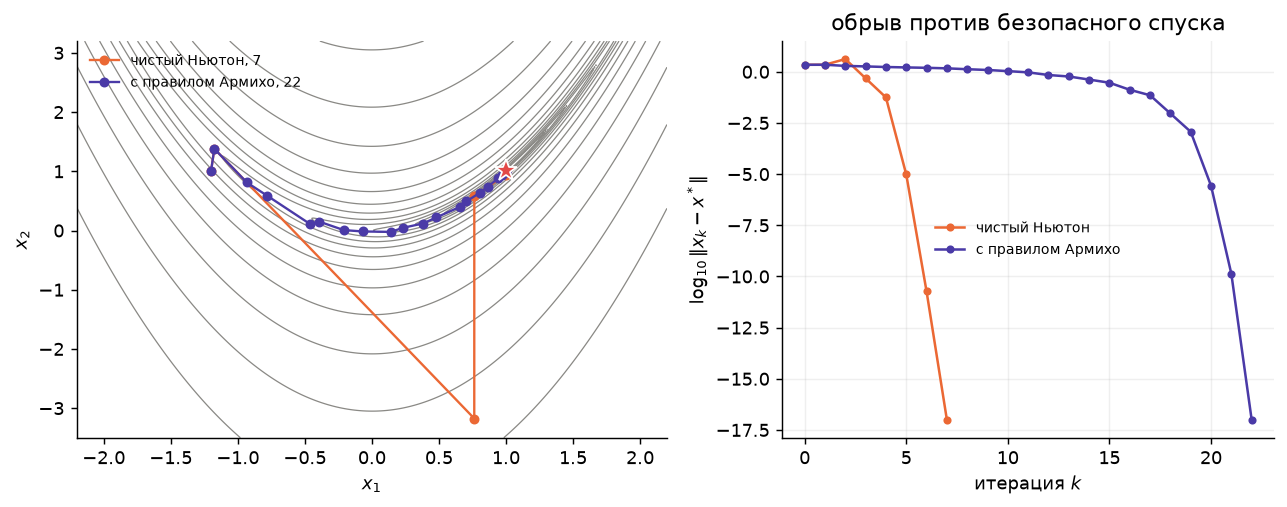

In [3]:
x_d, k_d, path_d = newton_damped(rosen, rosen_grad, rosen_hess, X0_ROSEN)
err_d = np.linalg.norm(path_d - 1, axis=1)
f_d = np.array([rosen(v) for v in path_d])
print(f"демпфированный Ньютон: {k_d} итераций (в конспекте 22), x = {x_d.round(8)};  f убывает на каждом шаге: {np.all(np.diff(f_d) < 0)};  наибольшая ошибка по пути {err_d.max():.3f} (у чистого Ньютона 4.18)")
print("ошибки:", np.array2string(err_d, precision=3, max_line_width=120))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1.2, 1]})
plot_rosen_path([path_n, path_d], [f"чистый Ньютон, {k_n}", f"с правилом Армихо, {k_d}"], ax=ax1)
plot_errors([err_n, err_d], ["чистый Ньютон", "с правилом Армихо"], ax=ax2)
ax2.set_title("обрыв против безопасного спуска"); plt.tight_layout(); plt.show()

**Предскажите до запуска.** Чистый Ньютон стартует из $(2,2)$ — точки под параболой, где гессиан $\succ0$ с $\kappa\approx108$. Сколько будет итераций: больше или меньше семи? А из $(0,0)$, где функция почти квадратична вдоль $x_2$ ($\lambda=2$ и $200$)? Измените `START` и проверьте.

In [4]:
START = (2.0, 2.0)          # измените и перезапустите; ответ — в следующей ячейке
x, k, path = newton(rosen_grad, rosen_hess, START)
print(f"из {START}: {k} итераций, ошибки {np.array2string(np.linalg.norm(path - 1, axis=1), precision=2)}")

из (2.0, 2.0): 5 итераций, ошибки [1.41e+00 3.15e+00 9.90e-01 2.76e-03 1.52e-06 6.45e-15]


Ответ: из $(2,2)$ — $5$ итераций (ошибка $1.41\to3.15\to0.99\to0.003\to\dots$: снова выброс, затем обрыв), из $(0,0)$ — $2$. Число итераций Ньютона не читается по $\kappa$ и даже по расстоянию до минимума: решает то, насколько квадратичная модель похожа на функцию вдоль пути.

## 4. Цена гессиана и квази-ньютоновские методы

### 4.1. Сколько стоит шаг Ньютона

Градиентный спуск: один градиент, $O(n)$ памяти и операций на шаг. Ньютон: гессиан — $n(n+1)/2$ вторых производных, которые нужно *вывести* (Розенброк — три формулы, цепь — матрица $\operatorname{diag}(DK,DK)$, модель с $10^4$ параметров — уже нет), плюс решение системы $n\times n$ — $O(n^3)$. Для цепи $N=400$ это $800\times800$ и доли секунды, для $n=10^5$ — невозможно.

Вопрос: нельзя ли получить кривизну даром — из того, что мы и так считаем?

### 4.2. Секущее уравнение: что мы измерили

Одна переменная. Два последних градиента $f'(x_k)$, $f'(x_{k+1})$ и расстояние $s_k=x_{k+1}-x_k$ между точками дают оценку второй производной — наклон секущей:

$$
f''\approx\frac{f'(x_{k+1})-f'(x_k)}{x_{k+1}-x_k}=\frac{y_k}{s_k},\qquad y_k=f'(x_{k+1})-f'(x_k).
$$

Это **метод секущих**: Ньютон, в котором $f''$ заменена разностным отношением. В $n$ измерениях мы хотим матрицу $B_{k+1}\approx\nabla^2f$, которая так же согласуется с последней парой $(s_k,y_k)$:

$$
\boxed{\;B_{k+1}s_k=y_k\;}\qquad s_k=x_{k+1}-x_k,\quad y_k=g_{k+1}-g_k.
$$

Это **секущее уравнение** (*secant equation*): кривизна модели вдоль только что пройденного направления равна измеренной. Для квадратичной функции оно точно: $y_k=Qs_k$. Но при $n>1$ уравнение даёт $n$ условий на $n(n+1)/2$ элементов симметричной матрицы — решений много. Нужно правило выбора.

<img src="img/08_secant.png" width="900" alt="график производной f' одной переменной: касательная в точке x_1 (шаг Ньютона) и секущая через x_0 и x_1 (шаг метода секущих)">

Итак, секущее уравнение говорит, *чему* должна удовлетворять новая матрица, но не говорит, *какую* из множества подходящих взять. Добавим два требования. Во-первых, матрица должна остаться положительно определённой — иначе шаг перестанет быть спуском. Во-вторых, она должна отличаться от прошлой как можно меньше: новой информации у нас ровно одна пара $(s_k,y_k)$ — кривизна вдоль последнего шага, — и всё, что матрица знала о других направлениях, менять не за что. Следующий пункт строит матрицу, которая выполняет все три условия, и это построение — формула BFGS.

### 4.3. Обновление BFGS: стереть старое, вписать измеренное

**Что храним.** Удобнее хранить не $B_k$, а сразу обратную матрицу $H_k\approx\nabla^2f(x_k)^{-1}$: тогда шаг $p_k=-H_kg_k$ — одно умножение, без решения системы. Секущее уравнение для обратной матрицы читается наоборот:

$$
H_{k+1}\,y_k=s_k .
$$

Три требования к $H_{k+1}$: (1) секущее уравнение; (2) симметрия и $H_{k+1}\succ0$ — тогда $p_{k+1}=-H_{k+1}g_{k+1}$ снова направление спуска; (3) от $H_k$ отличаться как можно меньше — менять только кривизну вдоль последнего шага, о которой пришла информация.

**Одна переменная.** Здесь всё определено: $H_{k+1}=s_k/y_k$ — обратный наклон секущей, метод секущих из §4.2. В $n$ измерениях надо из $H_k$ сделать матрицу, которая вдоль $y_k$ ведёт себя как $s_k/y_k$, а в остальном не меняется. Делаем это в два хода.

**Ход 1 — стереть.** Матрица

$$
P=I-\rho_k\,y_ks_k^\top,\qquad \rho_k=\frac1{y_k^\top s_k}
$$

стирает направление $y_k$ и не трогает всё, что ортогонально шагу $s_k$:

$$
Py_k=y_k-\rho_k\,y_k\,(s_k^\top y_k)=y_k-y_k=0,\qquad s_k^\top v=0\ \Rightarrow\ Pv=v .
$$

(Это проектор: $P^2=P$ — упражнение 11.6(а).) Произведение $P^\top H_kP$ — «старая матрица, которой запретили видеть $y_k$»: $(P^\top H_kP)\,y_k=P^\top H_k\,(Py_k)=0$.

**Ход 2 — вписать.** К стёртому добавим измеренное — слагаемое $\rho_ks_ks_k^\top$, которое переводит $y_k$ ровно в $s_k$:

$$
H_{k+1}=P^\top H_kP+\rho_k\,s_ks_k^\top .
$$

Проверяем секущее уравнение в одну строку: $H_{k+1}y_k=P^\top H_k(Py_k)+\rho_ks_k(s_k^\top y_k)=0+s_k$. Симметрия — по построению: оба слагаемых симметричны. В раскрытом виде это и есть **обновление BFGS** (Бройден, Флетчер, Гольдфарб, Шанно, 1970):

$$
\boxed{\;H_{k+1}=\big(I-\rho_ks_ky_k^\top\big)H_k\big(I-\rho_ky_ks_k^\top\big)+\rho_ks_ks_k^\top,\qquad\rho_k=\frac1{y_k^\top s_k}\;}
$$

**Что изменилось, а что нет.** Для любого $v$ с $s_k^\top v=0$ имеем $Pv=v$, поэтому $v^\top H_{k+1}v=(Pv)^\top H_k(Pv)+\rho_k(s_k^\top v)^2=v^\top H_kv$: на всех направлениях, ортогональных шагу, квадратичная форма осталась прежней — требование (3) выполнено. Поправка $H_{k+1}-H_k$ имеет ранг два: она составлена из векторов $s_k$ и $H_ky_k$. В одной переменной $P=1-\rho ys=0$, и формула даёт $H_{k+1}=\rho s^2=s/y$ — метод секущих. Та же формула получается и как решение задачи «ближайшая к $H_k$ симметричная матрица с $Hy=s$» в подходящей взвешенной норме (Nocedal & Wright, §6.1); нам достаточно построения.

**Положительная определённость.** Сначала — что без условия $s_k^\top y_k>0$ ничего не выйдет: если $s^\top y\le0$, то *никакая* матрица с $Hy=s$ не может быть $\succ0$, потому что $y^\top Hy=y^\top s\le0$. Теперь — что при $s_k^\top y_k>0$ формула знак сохраняет. Пусть $H_k\succ0$ и $z\ne0$; положим $w=Pz$. Тогда

$$
z^\top H_{k+1}z=w^\top H_kw+\rho_k\,(s_k^\top z)^2\ \ge\ 0,
$$

и равенство возможно только при $w=0$ и $s_k^\top z=0$ одновременно; но при $s_k^\top z=0$ имеем $w=Pz=z\ne0$. Значит $z^\top H_{k+1}z>0$: $H_{k+1}\succ0$, и следующий шаг — снова направление спуска.

Условие $s_k^\top y_k>0$ называют **условием кривизны** (*curvature condition*): вдоль пройденного шага градиент вырос в направлении шага, то есть кривизна положительна. На выпуклой функции оно выполнено при любом шаге; в общем случае его нужно обеспечить выбором длины шага. Для этого к правилу Армихо добавляют вторую проверку — **условие кривизны Вольфе** (*Wolfe curvature condition*): $\nabla f(x_k+\alpha p_k)^\top p_k\ge c_2\,g_k^\top p_k$ при $c_2=0.9$, то есть наклон вдоль направления после шага должен стать заметно менее отрицательным, чем был. Пара «Армихо + Вольфе» гарантирует $s^\top y>0$; так устроен линейный поиск в SciPy. Наш код в демо и ДЗ 3 обходится одним Армихо и просто пропускает обновление, если $s^\top y\le0$.

**Метод BFGS.** $H_0=I$ (первый шаг — градиентный); далее на каждой итерации: $p_k=-H_kg_k$; длина шага $\alpha_k$ по Армихо; $s_k=x_{k+1}-x_k$, $y_k=g_{k+1}-g_k$; если $s_k^\top y_k>0$ — обновить $H$ по формуле в рамке. В формуле лекции $B_k=H_k^{-1}$. Цена шага: $O(n^2)$ операций и памяти, **никаких вторых производных**.

**Та же формула для $B_k$.** Если хранить не обратную, а саму матрицу кривизны, обновление BFGS записывается как

$$
B_{k+1}=B_k-\frac{B_ks_ks_k^\top B_k}{s_k^\top B_ks_k}+\frac{y_ky_k^\top}{y_k^\top s_k}
$$

— вычесть то, что $B_k$ «знала» о направлении $s_k$, добавить измеренное; подстановкой $B_{k+1}s_k=y_k$. Что это в точности обратная к $H_{k+1}$ из рамки — упражнение 11.6(б). В литературе встречаются обе записи; в ДЗ 3 и на семинаре — формула для $H$.

### 4.4. BFGS учится эллипсу и сходится сверхлинейно

Квадратичная $f=\tfrac12(x_1^2+50x_2^2)$ из лекции 4, старт $(50,1)$, точный линейный поиск. $H_0=I$ — модель-круг. После первого шага и обновления модель знает кривизну вдоль пройденного направления; после второго — вдоль обоих: $H_2=Q^{-1}=\operatorname{diag}(1,\,0.02)$ **точно**, и метод в минимуме за $2$ итерации против $567$ у спуска с точным шагом. Это общий факт: на квадратичной функции BFGS с точным поиском восстанавливает $Q^{-1}$ и сходится не более чем за $n$ шагов.

<img src="img/09_bfgs_ellipses.png" width="900" alt="квадратичная функция с κ=50: эллипсы модели B_0=I, B_1, B_2 против эллипса истинного гессиана — после двух обновлений совпадение">

<img src="img/16_bfgs_learns.gif" width="900" alt="анимация: BFGS на Розенброке, итерация за итерацией; эллипс модели B_k вокруг текущей точки сближается с эллипсом истинного гессиана, собственные числа модели догоняют собственные числа гессиана">

На анимации — BFGS на Розенброке: оранжевый эллипс — модель $B_k$, чёрный — истинный гессиан в той же точке. Первые итерации модель-круг не похожа на функцию; к концу эллипсы совпадают по форме и наклону, и шаги становятся ньютоновскими.

<img src="img/10_rates_three.png" width="900" alt="Розенброк из (-1.2, 1): логарифм ошибки для градиентного спуска (прямая), BFGS (кривая загибается) и чистого Ньютона (обрыв)">

**Сверхлинейная сходимость.** Розенброк из $(-1.2,1)$: наш BFGS — $34$ итерации и $54$ вычисления $f$; `scipy.optimize.minimize(method="BFGS")` — $33$ итерации и $40$ вычислений. Кривая ошибки загибается всё круче, но не так резко, как у Ньютона: хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$ — $0.30,\ 0.016,\ 0.032,\ 0.014,\ 0.012$ — стремится к нулю, но не квадратично (там было бы $10^{-5}$). Это **сверхлинейная** сходимость, и она равносильна тому, что $B_k$ приближает гессиан вдоль направлений шагов (теорема Денниса–Морé, Nocedal & Wright, §6.4). Предупреждение: с одним лишь Армихо BFGS хрупок — на цепи $N=40$ он не сходится за $10\,000$ итераций, а SciPy с условием Вольфе сходится за $68$ (упражнение 11.9).

**Одной строкой.** Квази-Ньютон измеряет кривизну разностью градиентов и накапливает её в $H_k$ по секущему уравнению: стереть то, что матрица думала о направлении $y_k$, вписать измеренное $s_k$; BFGS сходится сверхлинейно за цену градиента.

### Демо (b). BFGS: кривизна из разности градиентов

Раздел 4 конспекта, упражнение 11.5. **Что проверяем.** На квадратичной $f=\tfrac12(x_1^2+50x_2^2)$ из $(50,1)$ с точным шагом BFGS восстанавливает обратный гессиан за два обновления: $H_2=Q^{-1}=\operatorname{diag}(1,\,0.02)$ точно, и $x_2=0$. Для сравнения: спуск с точным шагом на той же задаче — $567$ итераций (лекция 4).

In [5]:
Q = np.diag([1.0, 50.0])
f_q, grad_q = (lambda x: 0.5 * x @ Q @ x), (lambda x: Q @ x)
x_q, k_q, path_q, _ = bfgs(f_q, grad_q, [50.0, 1.0], tol=1e-10, Q=Q)
print(f"BFGS с точным шагом: {k_q} итерации, x = {x_q}")

# восстанавливаем H_k по пути, как в упражнении 11.5
H = np.eye(2)
for k in range(len(path_q) - 1):
    s = path_q[k + 1] - path_q[k]; y_ = Q @ s; rho = 1 / (s @ y_); I = np.eye(2)
    print(f"шаг {k}: s = {s.round(4)}, y = {y_.round(4)}, s^T y = {s @ y_:.4f} > 0")
    H = (I - rho * np.outer(s, y_)) @ H @ (I - rho * np.outer(y_, s)) + rho * np.outer(s, s)
    print(f"        H_{k + 1} =\n{H.round(6)}   проверка секущего уравнения H y = s: {np.allclose(H @ y_, s)}")
print("Q^{-1} =\n", np.linalg.inv(Q))
assert np.allclose(H, np.linalg.inv(Q), atol=1e-10)

BFGS с точным шагом: 2 итерации, x = [-7.10542736e-15  1.22124533e-15]
шаг 0: s = [-1.9608 -1.9608], y = [ -1.9608 -98.0392], s^T y = 196.0784 > 0
        H_1 =
[[ 1.941945 -0.018839]
 [-0.018839  0.020377]]   проверка секущего уравнения H y = s: True
шаг 1: s = [-48.0392   0.9608], y = [-48.0392  48.0392], s^T y = 2353.9216 > 0
        H_2 =
[[1.   0.  ]
 [0.   0.02]]   проверка секущего уравнения H y = s: True
Q^{-1} =
 [[1.   0.  ]
 [0.   0.02]]


**Розенброк.** Наш BFGS с $H_0=I$ и правилом Армихо должен дать $34$ итерации и $54$ вычисления $f$ (до $\lVert\nabla f\rVert\le10^{-6}$); `scipy.optimize.minimize(method="BFGS")` с тем же допуском — $33$ итерации и $40$ вычислений (к Армихо там добавлено условие кривизны Вольфе, §4.3, и шаги принимаются экономнее). Хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$ у BFGS стремится к нулю, но не квадратично — сверхлинейная сходимость. На графике (картинка 10 конспекта) спуск — прямая, BFGS — загибается, Ньютон — обрыв; спуск занимает секунды: $13\,756$ итераций.

свой BFGS:      34 итераций, 54 вычислений f (в конспекте 34 и 54), x = [1. 1.]
scipy BFGS:     33 итераций, 40 вычислений f (в конспекте 33 и 40)
хвост |e_(k+1)|/|e_k| у BFGS: [0.4656 0.1422 0.3047 0.0159 0.0322 0.0137]  (квадратичная дала бы ~1e-5)


спуск с правилом Армихо: 13756 итераций (в конспекте 13 756), 0.44 с


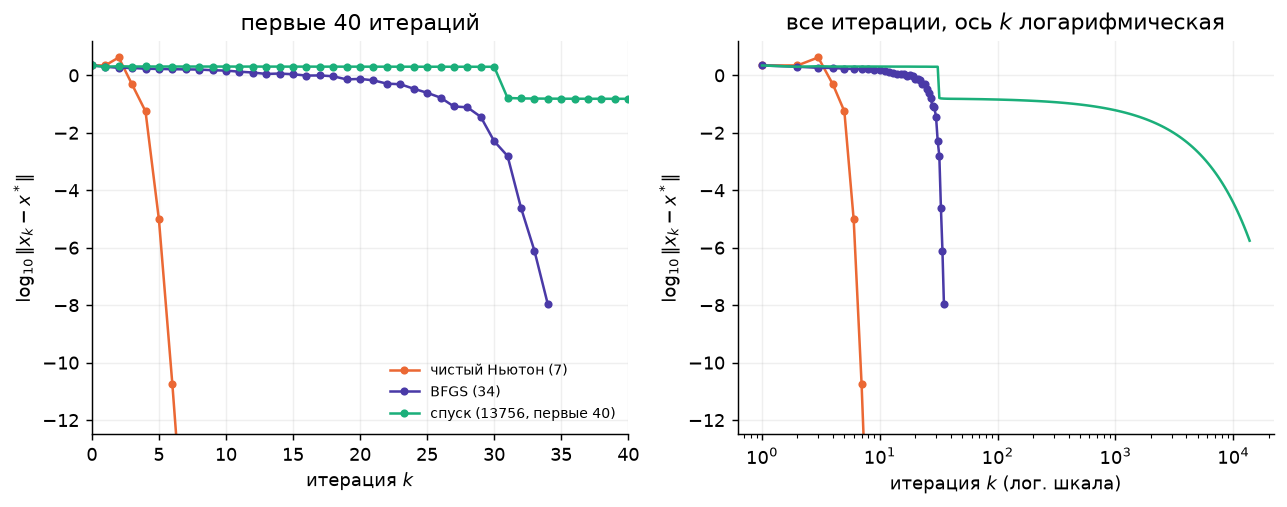

In [6]:
x_b, k_b, path_b, nfev_b = bfgs(rosen, rosen_grad, X0_ROSEN)
err_b = np.linalg.norm(path_b - 1, axis=1)
print(f"свой BFGS:      {k_b} итераций, {nfev_b} вычислений f (в конспекте 34 и 54), x = {x_b.round(7)}")
r_bfgs = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="BFGS", options={"gtol": 1e-6})
print(f"scipy BFGS:     {r_bfgs.nit} итераций, {r_bfgs.nfev} вычислений f (в конспекте 33 и 40)")
print("хвост |e_(k+1)|/|e_k| у BFGS:", np.array2string(err_b[-6:] / err_b[-7:-1], precision=4), " (квадратичная дала бы ~1e-5)")

t0 = time.perf_counter(); x_g, k_g, path_g = gd(rosen, rosen_grad, X0_ROSEN); t_gd = time.perf_counter() - t0
err_g = np.linalg.norm(path_g - 1, axis=1)
print(f"спуск с правилом Армихо: {k_g} итераций (в конспекте 13 756), {t_gd:.2f} с")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_errors([err_n, err_b, err_g[:41]], [f"чистый Ньютон ({k_n})", f"BFGS ({k_b})", f"спуск ({k_g}, первые 40)"], ax=ax1)
ax1.set(xlim=(0, 40), ylim=(-12.5, 1.2), title="первые 40 итераций")
plot_errors([err_n, err_b, err_g], ax=ax2, logx=True); ax2.set(ylim=(-12.5, 1.2), title="все итерации, ось $k$ логарифмическая")
plt.tight_layout(); plt.show()

## 5. Ньютон для суммы квадратов: Гаусс–Ньютон и Левенберг–Марквардт

### 5.1. Задача: подгонка кривой как сумма квадратов

Вернёмся к синусу из §1.2 и запишем задачу аккуратно. Есть $m=60$ измерений $(t_i,y_i)$ и модель с $n=3$ параметрами $x=(x_1,x_2,x_3)$ — амплитуда, частота, фаза:

$$
\varphi(t;x)=x_1\sin(x_2t+x_3).
$$

**Невязка** (*residual*) $i$-го измерения — вертикальный зазор между кривой и точкой: $r_i(x)=\varphi(t_i;x)-y_i$. Все $m$ невязок собираем в вектор $r(x)\in\mathbb R^m$, и подгонка — это **нелинейный метод наименьших квадратов** (*nonlinear least squares*):

$$
\min_{x\in\mathbb R^n}\ f(x)=\tfrac12\lVert r(x)\rVert^2=\tfrac12\sum_{i=1}^m r_i(x)^2 .
$$

<img src="img/11_residuals.png" width="900" alt="слева: данные синуса, кривая модели в старте (1, 3, 0) и невязки — вертикальные отрезки от точек до кривой; справа: три столбца якобиана невязок как функции t — отклик кривой на изменение амплитуды, частоты и фазы">

Слева — данные и кривая в старте $(1,3,0)$: оранжевые отрезки и есть невязки $r_i$, их $60$, а $f$ — половина суммы их квадратов. Справа — как кривая отзывается на каждый из трёх параметров; это столбцы матрицы, с которой работает весь раздел.

**Обозначения раздела.** Всё, что нужно методам, выражается через $r$ и его первые производные.

| Символ | Что это | Размер |
|---|---|---|
| $x$ | параметры модели | $n$ (у синуса $3$) |
| $r(x)$ | вектор невязок | $m$ ($60$) |
| $J(x)$, $J_{ij}=\partial r_i/\partial x_j$ | якобиан невязок: строка $i$ — как $i$-я невязка реагирует на параметры | $m\times n$ ($60\times3$) |
| $\nabla f=J^\top r$ | градиент $f$ | $n$ |
| $J^\top J$ | «бесплатная половина» гессиана | $n\times n$ ($3\times3$) |
| $\nabla^2r_i$ | гессиан одной невязки | $n\times n$, их $m$ штук |
| $S(x)=\sum_{i=1}^m r_i\,\nabla^2r_i$ | «дорогая половина» гессиана | $n\times n$ |
| $r_k$, $J_k$, $S_k$ | то же в текущей точке $x_k$ | |

Для синуса якобиан выписывается руками: строка $i$ — производные $\varphi(t_i;x)$ по амплитуде, частоте и фазе:

$$
J(x)=\begin{pmatrix}\vdots&\vdots&\vdots\\ \sin(x_2t_i+x_3)&x_1t_i\cos(x_2t_i+x_3)&x_1\cos(x_2t_i+x_3)\\ \vdots&\vdots&\vdots\end{pmatrix}\in\mathbb R^{60\times3}.
$$

Заметьте: при $x_1=0$ второй и третий столбцы нулевые, $J$ имеет ранг один. Это пригодится дважды.

**Градиент и гессиан.** Дифференцируем $f=\tfrac12\sum_ir_i^2$ по компонентам:

$$
\frac{\partial f}{\partial x_j}=\sum_{i=1}^m r_i\,\frac{\partial r_i}{\partial x_j}=(J^\top r)_j,\qquad
\frac{\partial^2f}{\partial x_j\partial x_l}=\sum_{i=1}^m\frac{\partial r_i}{\partial x_j}\,\frac{\partial r_i}{\partial x_l}+\sum_{i=1}^m r_i\,\frac{\partial^2r_i}{\partial x_j\partial x_l}=(J^\top J)_{jl}+S_{jl}.
$$

Итого

$$
\boxed{\;\nabla f=J^\top r,\qquad \nabla^2f=J^\top J+S\;}
$$

Первая половина гессиана, $J^\top J$, собирается из тех же первых производных, что и градиент, — она **бесплатна**. Вторая, $S$, требует гессианы всех $m$ невязок — дорого — и пропорциональна самим невязкам $r_i$: там, где кривая проходит близко к точкам, $S$ мала.

**Ньютон для этой задачи** (§2.2) — система $n\times n$ с полным гессианом:

$$
\big(J_k^\top J_k+S_k\big)\,p_k=-J_k^\top r_k .
$$

Это точный ньютоновский шаг; он требует $S_k$, и именно он на синусе из §1.2 ушёл в точку с $x_1=0$.

### 5.2. Гаусс–Ньютон: Ньютон, который отбросил дорогую половину

**Идея.** Выбросим $S_k$ и оставим бесплатную половину: $B_k=J_k^\top J_k$. Это **метод Гаусса–Ньютона** (*Gauss–Newton*):

$$
\boxed{\;J_k^\top J_k\,p_k=-J_k^\top r_k\;}
$$

**Второй вывод — через линеаризацию невязки.** Как в §2.1, линеаризуем — но не градиент, а вектор невязок: $r(x_k+p)\approx r_k+J_kp$ (вектор длины $m$). Подставим в $f$:

$$
f(x_k+p)\approx\tfrac12\lVert J_kp+r_k\rVert^2 .
$$

Минимизация по $p$ — обычный **линейный** МНК из лекции 1 (§7.1) с матрицей $J_k$ ($m\times n$) и правой частью $-r_k$: условие минимума $J_k^\top(J_kp+r_k)=0$ — та же система. Значит, шаг Гаусса–Ньютона — это линейная задача подгонки, решённая в текущей точке; в коде `np.linalg.lstsq(J, -r)`, и вторых производных нет вовсе. Если невязки линейны по $x$, один шаг даёт точный ответ (упражнение 11.7(г)).

**Алгоритм.** Из $x_0$ повторять:

1. вычислить $r_k=r(x_k)$ (вектор $m$) и $J_k=J(x_k)$ (матрица $m\times n$);
2. найти $p_k$ — решение линейного МНК $\min_p\lVert J_kp+r_k\rVert^2$ (вектор $n$);
3. $x_{k+1}=x_k+\alpha_kp_k$: $\alpha_k=1$ — чистый метод, $\alpha_k$ по правилу Армихо из §3.4 — демпфированный;
4. остановиться, когда $\lVert J_k^\top r_k\rVert\le\varepsilon$ — это норма градиента.

**Три свойства.**

- *Всегда спуск.* Если столбцы $J_k$ линейно независимы, то $J_k^\top J_k\succ0$ и $g_k^\top p_k=-r_k^\top J_k(J_k^\top J_k)^{-1}J_k^\top r_k<0$. Седловой модели у Гаусса–Ньютона не бывает по построению — в отличие от Ньютона с полным гессианом.
- *Скорость.* Ошибка модели — отброшенный член $S$. Вблизи решения (Nocedal & Wright, теорема 10.1)
  $$
  \lVert e_{k+1}\rVert\le C_1\lVert S^\ast\rVert\,\lVert e_k\rVert+C_2\lVert e_k\rVert^2,\qquad S^\ast=S(x^\ast):
  $$
  при малых невязках (данные почти без шума, модель почти линейна) линейный член мал, и сходимость почти квадратичная; при больших невязках она линейная с множителем порядка $\lVert S^\ast\rVert$ и может пропасть вовсе.
- *Где ломается.* Если столбцы $J_k$ почти зависимы, $J_k^\top J_k$ почти вырождена, и шаг $p_k$ огромен и ненадёжен — у синуса так при $x_1\approx0$.

**Синус из §1.2.** Из старта $(1,3,0)$ Гаусс–Ньютон сходится за $7$ итераций к $x^\ast=(2.1014,\ 2.9967,\ 0.7003)$, $f^\ast=1.1393$:

| $k$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|---|
| $\lVert e_k\rVert$ | $1.3$ | $0.83$ | $0.45$ | $0.047$ | $0.0018$ | $3\cdot10^{-5}$ | $10^{-6}$ |

Формально сходимость линейная, но множитель в хвосте $\approx0.02$ — на графике не отличить от обрыва. Причина — малые невязки: шум $0.2$ при амплитуде $2$. В решении собственные числа двух половин гессиана почти совпадают:

| Матрица в $x^\ast$ | $\lambda_1$ | $\lambda_2$ | $\lambda_3$ |
|---|---|---|---|
| $J^\top J$ | $17.6$ | $31.1$ | $1935.6$ |
| $\nabla^2f=J^\top J+S$ | $17.9$ | $31.1$ | $1927.3$ |

Отличие меньше $2\,\%$: отброшенная половина в решении почти ничего не весит.

<img src="img/12_gn_sine.png" width="900" alt="подгонка синуса из ДЗ 2: данные и кривые Гаусса–Ньютона и Ньютона (нулевая амплитуда); справа ошибки Гаусса–Ньютона и градиентного спуска">

**Почему Ньютон ушёл в нуль, а Гаусс–Ньютон — нет.**

- При $x_1=0$ столбцы $J$ по частоте и фазе нулевые, так что $\partial f/\partial x_2=\partial f/\partial x_3=0$ автоматически, а $\partial f/\partial x_1=-\sum_i\sin(x_2t_i+x_3)\,y_i$ обращается в нуль, когда синус с такими частотой и фазой ортогонален данным. Таких $(x_2,x_3)$ — целые кривые, и все эти точки стационарные: $f=\tfrac12\lVert y\rVert^2\approx64$.
- Полный гессиан вдали от решения содержит большой член $S$ и делает модель седловой; Ньютон решает $\nabla f=0$ и за $9$ итераций приходит к ближайшему нулю градиента — к модели «ноль».
- У Гаусса–Ньютона $J^\top J\succeq0$: каждый шаг — вниз по $f$, а в точках с $x_1=0$ значение $f$ *больше* стартового. Туда он прийти не может. Отброшенный член не только дорог, но и вреден вдали от решения.

**Когда брать Гаусса–Ньютона.**

- Задача — нелинейный МНК с малыми невязками или хорошо линеаризуемой моделью.
- Есть приличное начальное приближение.
- Столбцы $J$ независимы: параметры не дублируют друг друга.
- Вторые производные считать не хочется или невозможно.

### 5.3. Левенберг–Марквардт: тот же сдвиг, что $\tau I$

**Зачем.** Два слабых места Гаусса–Ньютона — ровно те, что были у Ньютона в §3.4:

- $J_k^\top J_k$ вырождена или почти вырождена — шаг не определён или огромен (синус при $x_1\approx0$);
- из плохого старта линейная модель невязок врёт на всей длине шага, и $f$ после шага больше, чем до.

Лечение — тот же сдвиг, что в §3.4, только теперь он не разовый, а управляемый:

$$
\boxed{\;\big(J_k^\top J_k+\lambda_kI\big)\,p_k=-J_k^\top r_k,\qquad\lambda_k\ge0\;}
$$

— система $n\times n$, $I$ — единичная матрица $n\times n$. Это **метод Левенберга–Марквардта** (*Levenberg–Marquardt*); в формуле лекции $B_k=J_k^\top J_k+\lambda_kI$, $\alpha_k=1$. (В масштабированном варианте вместо $I$ берут $\operatorname{diag}(J_k^\top J_k)$, чтобы сдвиг не зависел от единиц измерения параметров; так делает SciPy.)

**Откуда берётся.** К линейному МНК шага добавим штраф за длину шага:

$$
\min_p\ \lVert J_kp+r_k\rVert^2+\lambda\lVert p\rVert^2 .
$$

Производная по $p$: $2J_k^\top(J_kp+r_k)+2\lambda p=0$ — это и есть система в рамке. Прочтение: шаг минимизирует линейную модель невязок, но не уходит далеко от $x_k$ — остаётся в шаре $\lVert p\rVert\le\Delta$, где этой модели ещё можно верить; чем больше $\lambda$, тем меньше шар.

**Два предела.**

| $\lambda$ | Система | Шаг |
|---|---|---|
| $\lambda\to0$ | $J_k^\top J_kp=-J_k^\top r_k$ | Гаусс–Ньютон: длинный, по модели |
| $\lambda\to\infty$ | $\lambda p\approx-J_k^\top r_k$ | $p\approx-\tfrac1\lambda\nabla f$: короткий градиентный, длина $1/\lambda$ |

Между пределами $\lambda$ **интерполирует**: с ростом $\lambda$ шаг укорачивается и поворачивает от направления Гаусса–Ньютона к антиградиенту. Вместо длины шага $\alpha$, как у Армихо, метод подкручивает $\lambda$.

<img src="img/13_lm_steps.png" width="900" alt="слева: линии уровня f на срезе синуса по амплитуде и частоте и стрелки шага из одной точки при λ = 0, 10, 100, 1000 — шаг укорачивается и поворачивает к антиградиенту; справа: путь Левенберга–Марквардта с подписанными λ_k сходится к минимуму, путь чистого Гаусса–Ньютона прыгает по бассейнам">

Слева — срез задачи с синусом при зафиксированной фазе $x_3=0.70$: линии уровня $f$ по амплитуде и частоте и старт $(0.5,\,3.15)$ — амплитуда мала, столбец $J$ по частоте мал. Шаг Гаусса–Ньютона ($\lambda=0$) длиной $1.47$ уводит в точку с $f=95$ против $43$ в старте; при $\lambda=10$ шаг короче, но всё ещё вверх — $f=64$; при $\lambda=100$ — вниз, $f=29$, и стрелка почти вдоль антиградиента; при $\lambda=1000$ шаг уже слишком короткий, $f=39$. Справа — что делает правило подбора $\lambda$: Левенберг–Марквардт из того же старта за $19$ итераций приходит в минимум $f^\ast=1.1393$, по дороге $9$ раз отвергая шаг и поднимая $\lambda$ до $53$, а у минимума отпуская его к нулю — там он снова Гаусс–Ньютон. Чистый Гаусс–Ньютон из той же точки прыгает между бассейнами и за $30$ итераций не сходится ($f\approx60$).

**Алгоритм.** Старт $x_0$, $\lambda_0=10^{-3}\max_i(J_0^\top J_0)_{ii}$. На каждой итерации:

1. вычислить $r_k$, $J_k$ и $f(x_k)=\tfrac12\lVert r_k\rVert^2$;
2. решить систему в рамке с текущим $\lambda$ — получить $p$ и пробную точку $x_k+p$;
3. сравнить фактическое уменьшение $f$ с тем, что обещала линейная модель $L(p)=\tfrac12\lVert r_k+J_kp\rVert^2$, — **отношение выигрыша** (*gain ratio*)
   $$
   \rho=\frac{f(x_k)-f(x_k+p)}{L(0)-L(p)}\qquad(\text{знаменатель}\ge0\ \text{всегда});
   $$
4. по $\rho$ решить, принимать ли шаг и куда двинуть $\lambda$:

| $\rho$ | Модель | Шаг | $\lambda$ |
|---|---|---|---|
| $\rho>0.75$ | хороша | принять | $\lambda/3$ — ближе к Гауссу–Ньютону |
| $0.25\le\rho\le0.75$ | терпима | принять | не менять |
| $0<\rho<0.25$ | плоха | принять | $2\lambda$ |
| $\rho\le0$ | шаг вверх | **отвергнуть**, решить заново | $2\lambda$ |

5. остановиться при $\lVert J_k^\top r_k\rVert\le\varepsilon$ или когда шаг $\lVert p\rVert$ стал ничтожным.

Полный код — упражнение 11.7(д): на синусе из старта ДЗ 2 №1 это $9$ итераций без единого отвергнутого шага.

**Свойства.**

- При $\lambda>0$ матрица $J_k^\top J_k+\lambda I\succ0$ всегда, даже при вырожденном $J_k$: система решается, шаг — спуск.
- Устойчив из плохого старта и при больших невязках: пока модель врёт, $\lambda$ велико и метод идёт короткими градиентными шагами; как только модель стала хороша, $\lambda\to0$ и возвращается скорость Гаусса–Ньютона.
- Когда Гаусс–Ньютон и так хорош, Левенберг–Марквардт чуть медленнее: часть шагов укорочена зря.
- $\lambda$ настраивается сам; крутить пользователю нечего.

Это стандарт для подгонки кривых: в SciPy — `scipy.optimize.least_squares(..., method="lm")`, на синусе из $(1,3,0)$ — $7$ вычислений невязки и тот же $x^\ast$. Локальность никуда не делась: из $20$ случайных стартов ДЗ 2 демпфированный Гаусс–Ньютон приходит к глобальному $f^\ast=1.1393$ в $12$ случаях, остальные — в локальные минимумы с другой частотой. Быстрый локальный метод не отменяет мультистарта, но делает каждый старт дешёвым.

**Одной строкой.** Гаусс–Ньютон — это Ньютон для суммы квадратов с гессианом $J^\top J$ (бесплатная половина, всегда спуск, почти квадратичная скорость при малых невязках); Левенберг–Марквардт — Гаусс–Ньютон со сдвигом $\lambda I$, который по отношению выигрыша сам балансирует между Гауссом–Ньютоном и градиентным спуском.

## 6. Таблица заполнена: три задачи, пять методов

| Метод | Что решает | $B_k$ | Что нужно | Цена шага | Сходимость | Розенброк из $(-1.2,1)$ |
|---|---|---|---|---|---|---|
| Ньютон для уравнений | $F(x)=0$ | якобиан $J_F$ | $F$, $J_F$ | $O(n^3)$ | квадратичная вблизи корня | — |
| градиентный спуск | $\min f$ | $I$ | $\nabla f$ | $O(n)$ | линейная, $\propto\kappa$ | $13\,756$ |
| Ньютон | $\min f$ через $\nabla f=0$ | $\nabla^2f(x_k)$ | $\nabla f$, $\nabla^2f$, решение системы | $O(n^3)$ | квадратичная вблизи; вдали может уйти | $7$ (с Армихо — $22$) |
| BFGS | $\min f$ | $H_k^{-1}$ по секущему уравнению | $\nabla f$ | $O(n^2)$ | сверхлинейная | $34$ (SciPy — $33$) |
| Гаусс–Ньютон | $\min\tfrac12\lVert r\rVert^2$ | $J^\top J$ | $r$, $J$ | $O(mn^2)$ | почти квадратичная при малых невязках | синус: $7$ против $731$ у спуска |
| Левенберг–Марквардт | $\min\tfrac12\lVert r\rVert^2$ | $J^\top J+\lambda I$ | $r$, $J$ | $O(mn^2)$ | надёжная: от линейной до квадратичной | синус: $7$ вычислений $r$ |

**Биография цепи.** Одна и та же выпуклая квадратичная задача, $N=40$, $80$ переменных, останов по $\lVert\nabla E\rVert\le10^{-6}$:

| Лекция | Метод | Итераций | Что нового |
|---|---|---|---|
| 1 | солвер как чёрный ящик | — | постановка задачи |
| 4 | градиентный спуск, шаг $1/L$ | $10\,575$ | $\propto\kappa=681$ |
| 5 | Ньютон | $1$ | модель точна: один `np.linalg.solve` |
| 5 | BFGS, точный шаг | $20$ | не больше числа различных собственных чисел гессиана |

<img src="img/14_chain_methods.png" width="900" alt="цепь: число итераций градиентного спуска и BFGS в зависимости от числа грузов N; Ньютон — одна итерация">

Спуск растёт как $N^2$ (за $\kappa$), BFGS — как $N/2$ (точный поиск на квадратичной), Ньютон — константа. При $N=160$ спуск делает $155\,943$ итерации и около $10$ секунд, Ньютон — миллисекунды. Но Ньютон хранит и решает систему $2N\times2N$, а BFGS хранит плотную $H_k$ того же размера: при $N=10^5$ ни ту, ни другую уже не разместить — это граница сегодняшних методов.

**Одной строкой.** Ньютон — линеаризуй и реши; Ньютон для оптимизации — Ньютон для $\nabla f=0$ с гессианом; BFGS — Ньютон с кривизной, выученной из градиентов; Гаусс–Ньютон — Ньютон для суммы квадратов с $J^\top J$; Левенберг–Марквардт — Гаусс–Ньютон со сдвигом $\lambda I$. Чем больше кривизны знает $B_k$, тем меньше итераций и дороже каждая: $O(n)$, $O(n^2)$, $O(n^3)$ за шаг.

## 7. Что это даёт численно

- **Диагноз по графику** $\log\lVert\nabla f(x_k)\rVert$: прямая — метод первого порядка, читайте $\kappa$ (Л4, §5); кривая загибается всё круче — квази-Ньютон работает; обрыв — ньютоновская область. Горб в начале у Ньютона — модель врала, нужен Армихо.
- **Стационарная точка — ещё не минимум**, и Ньютон этого не проверяет: собственные числа гессиана в найденной точке (Л4, §3) — обязательный финальный шаг.
- **`scipy.optimize.minimize`**: `BFGS` по умолчанию (градиент — аналитический через `jac=` или конечные разности). **Подгонка кривых** — всегда `scipy.optimize.least_squares` (внутри Левенберг–Марквардт), а не `minimize` суммы квадратов: структура $J^\top J$ стоит нескольких порядков скорости, а $\lambda$ страхует от плохого старта.
- **ДЗ 3**: вы напишете направление Ньютона с регуляризацией, шаг по Армихо, обновление BFGS и шаг Гаусса–Ньютона сами и воспроизведёте числа этой лекции на Розенброке, цепи и синусе. Сцена «Ньютон против спуска» на [интерактивной странице](https://claude.ai/artifact/9NaEBdf8cjpnMbYEdW8Zy2) показывает те же $13\,756$ / $7$ / $22$ / $34$ из любого старта.

## 8. Итоги лекции

1. Все методы лекции — одна формула $x_{k+1}=x_k-\alpha_kB_k^{-1}\nabla f(x_k)$; отличается только то, что $B_k$ знает о кривизне (введение, раздел 6).
2. Ньютон — «линеаризуй и реши»: для уравнения $F=0$ с якобианом, для минимума — с гессианом, потому что минимум — это $\nabla f=0$; тот же шаг — минимум квадратичной модели. Длину шага задаёт модель, координаты метод не замечает (раздел 2).
3. Вблизи минимума ошибка возводится в квадрат: $\lVert e_{k+1}\rVert\le\frac M{2m}\lVert e_k\rVert^2$ — на графике $\log\lVert e_k\rVert$ обрыв, $7$ итераций на Розенброке (раздел 3).
4. Вдали модель врёт: Ньютон приходит в сёдла и максимумы ($36\,\%$ стартов на Химмельблау), а при индефинитном гессиане может шагнуть вверх; правило Армихо чинит длину шага ($22$ итерации), сдвиг $\tau I$ — седловую модель (раздел 3).
5. Секущее уравнение $B_{k+1}s_k=y_k$ измеряет кривизну разностью градиентов; BFGS строит $H_{k+1}$ в два хода — стереть направление $y_k$, вписать $s_k$ — и сохраняет $\succ0$ при $s^\top y>0$; сходимость сверхлинейная, $34$ итерации без единой второй производной (раздел 4).
6. Гаусс–Ньютон — Ньютон для суммы квадратов с гессианом $J^\top J$ (бесплатная половина): всегда спуск, $7$ итераций против $731$; Левенберг–Марквардт — Гаусс–Ньютон со сдвигом $\lambda I$, который по отношению выигрыша $\rho$ сам балансирует между Гауссом–Ньютоном и градиентным спуском; на цепи $10\,575\to20\to1$ (разделы 5–6).

## 9. Что дальше

**Лекция 6** — глобализация: как выбирать длину шага и радиус доверия модели так, чтобы любой из сегодняшних методов сходился из любого старта, и метод сопряжённых градиентов. **Лекция 7** — как считать производные: конечные разности и алгоритмическое дифференцирование, CasADi всерьёз. **L-BFGS** — BFGS, который хранит только $m$ последних пар $(s_k,y_k)$ и не строит матрицу $n\times n$, — метод для миллиона переменных: бонус ДЗ 3, Nocedal & Wright, §7.2.

**ДЗ 3** выдаётся сегодня, срок — 21 октября: градиентный спуск, Ньютон, BFGS и Гаусс–Ньютон — реализация и сравнение на задачах этой лекции ([карточка](../../homeworks/hw03.md), [ноутбук](../../homeworks/hw03.ipynb)). **ДЗ 2** — срок сегодня.

**Литература к лекции.** Diehl, гл. 5–6 (Newton-type methods, local convergence); Nocedal & Wright, §3.3 (Newton), гл. 6 (quasi-Newton, BFGS), §7.2 (L-BFGS), §10.1–10.3 (least squares, Gauss–Newton, Levenberg–Marquardt); Boyd & Vandenberghe, §9.5 (Newton's method); Поляк, гл. 1 (метод Ньютона и квазиньютоновские методы).

## 10. Семинар: свой Ньютон и BFGS против SciPy

Весь семинар — за ноутбуком [`seminar05.ipynb`](seminar05.ipynb) (~30 минут), только numpy и scipy. Пишем методы сами по формулам лекции, каждое число сверяем с конспектом и со SciPy.

| Мин | Часть |
|-----|------|
| 12 | **Часть 1 — Ньютон.** Чистый Ньютон за десять строк: $7$ итераций, таблица ошибок, выброс итерации 2; вопрос залу: `minimize(method="BFGS")` без единой второй производной — $33$ итерации, как?; добавляем Армихо — $22$ |
| 18 | **Часть 2 — BFGS и Гаусс–Ньютон.** Секущее уравнение на квадратичной: два обновления — и $H_2=Q^{-1}$ (упражнение 11.5); BFGS на Розенброке — $34$ итерации и $54$ вызова против $33$ и $40$ у SciPy, и почему; соревнование «из какого старта BFGS сойдётся быстрее всех?»; Гаусс–Ньютон на синусе ДЗ 2 — $7$ против $731$ у спуска и против Ньютона в $x_1=0$ |

Дома: 11.0–11.4, 11.6, 11.8–11.10; 11.5 и 11.7 — повторение семинара. Затем демонстрации (a)–(d) в `demo05.ipynb`.

## 11. Упражнения

Для разбора на занятии и самостоятельно. У каждой задачи курсивом — её суть одной фразой. Подробный разбор с проверкой кодом — ноутбук [`exercises05.ipynb`](exercises05.ipynb), краткие ответы — [`exercises05.md`](exercises05.md).

**11.0. Разминка — счёт руками.** Шесть пунктов по минуте. *Суть: шаг Ньютона, секущая и структура МНК — на бумаге, без компьютера.*

- (а) $f(x)=\tfrac12(x_1^2+9x_2^2)-x_1-9x_2$. Сделайте один шаг Ньютона из $(0,0)$. Куда попали? Проверьте, что $\nabla f=0$.
- (б) $\sqrt2$ методом Ньютона для $F(x)=x^2-2$ из $x_0=1$: выпишите $x_1,x_2,x_3$ и ошибки $e_k=x_k-\sqrt2$; проверьте, что $e_{k+1}=e_k^2/(2x_k)$.
- (в) Метод секущих для $f(x)=x^4$: по точкам $x_0=1$, $x_1=0.5$ оцените $f''$ через $y/s$ и сравните с $f''(0.5)=3$ и $f''(1)=12$.
- (г) $f=\tfrac12\lVert r\rVert^2$, $r(x)=(x_1-1,\ x_1x_2)$. Выпишите $J$, $J^\top J$ и полный $\nabla^2f$. Какой член отбрасывает Гаусс–Ньютон и когда он равен нулю?
- (д) Повторение Л4: $\kappa$ гессиана Розенброка в $(1,1)$ по следу и определителю ($\operatorname{tr}=1002$, $\det=400$). Почему это число не влияет на метод Ньютона?
- (е) $B=\operatorname{diag}(1,-1)$. Для $g=(1,0)$ и для $g=(0,1)$ найдите $p=-B^{-1}g$ и знак $g^\top p$: спуск или подъём?

**11.1. Два прочтения шага Ньютона.** *Суть: минимум модели и нуль линеаризованного градиента — одна формула; координаты она не видит.*

- (а) Покажите, что $\nabla m_k(p)=0$ и линеаризация $\nabla f(x_k+p)\approx0$ дают один и тот же $p$.
- (б) Докажите аффинную инвариантность: при $x=Au$ градиент и гессиан переходят в $A^\top\nabla f$ и $A^\top\nabla^2f\,A$, а шаги связаны как $A\tilde p=p$ (§2.2).
- (в) Градиентный спуск такой инвариантностью не обладает: покажите на $f=\tfrac12(x_1^2+25x_2^2)$ и замене $u_2=5x_2$, что шаг $-\alpha\nabla\tilde f$ в $u$ не равен пересчитанному шагу $-\alpha\nabla f$ в $x$.

**11.2. Квадратичная сходимость в $n$ измерениях** (домашняя). *Суть: ошибка Ньютона — это ошибка модели, а она квадратична.*

- (а) Докажите теорему §3.1 в $n$ измерениях. План: $e_{k+1}=\nabla^2f(x_k)^{-1}\big(\nabla^2f(x_k)e_k-g_k\big)$; по формуле Ньютона–Лейбница $g_k=\int_0^1\nabla^2f(x^\ast+te_k)\,e_k\,dt$; расстояние от $x_k$ до $x^\ast+te_k$ равно $(1-t)\lVert e_k\rVert$. Укажите, где используется липшицевость гессиана и где — $\nabla^2f\succeq mI$.
- (б) Для Розенброка оцените $M$ (норму производной гессиана по $x$ в окрестности $(1,1)$) и $m=\lambda_{\min}=0.3994$. Чему равен радиус шара, в котором теорема гарантирует сходимость?
- (в) Сравните $C=M/2m$ с измеренными $C_k=\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ по таблице §3.2. Почему оценка настолько пессимистична?

**11.3. Сломай метод.** *Суть: у Ньютона есть порог старта, за которым он расходится; демпфирование снимает порог.*

- (а) Для $f=\ln\cosh x$ выпишите итерацию и найдите численно порог $x_0^\ast$, при котором $x_1=-x_0$ (2-цикл). Ответ $\approx1.0886$.
- (б) То же для решения $\arctan x=0$ методом Ньютона: порог $\approx1.3917$.
- (в) Объясните по картинке §2.3, почему ниже порога метод сходится, а выше — расходится.
- (г) Добавьте к шагу правило Армихо для $f=\ln\cosh x$. Сходится ли метод из $x_0=5$? За сколько итераций?

**11.4. Ньютон на седловой модели и демпфирование.** *Суть: при индефинитном гессиане «минимум модели» — седло, и шаг может вести вверх.*

- (а) $f=x_1^2-x_2^2+x_2^4/4$: найдите стационарные точки и их тип. Покажите, что из любой точки с $x_2^2<1/3$ шаг Ньютона ведёт в седло $(0,0)$.
- (б) Для Розенброка проверьте: $\det\nabla^2f=80\,000\,(x_1^2-x_2+0.005)$, так что гессиан индефинитен при $x_2>x_1^2+0.005$. Приведите точку, где $g^\top p>0$ для ньютоновского $p$.
- (в) Почему вблизи минимума демпфированный Ньютон принимает $\alpha=1$ и сохраняет квадратичную сходимость? Подсказка: Армихо с $c<1/2$ и квадратичная модель, которая точна в пределе.

**11.5. BFGS руками.** *Суть: два обновления на квадратичной $2\times2$ восстанавливают $Q^{-1}$ целиком.* Разбирается на семинаре.

- (а) $f=\tfrac12(x_1^2+50x_2^2)$, $x_0=(50,1)$, $H_0=I$. Первый шаг — градиентный с точным $\alpha=\lVert g\rVert^2/g^\top Qg$ (Л4, §4.4). Выпишите $s_0$, $y_0=Qs_0$ и проверьте $s_0^\top y_0>0$.
- (б) Вычислите $H_1$ по формуле BFGS и проверьте $H_1y_0=s_0$.
- (в) Сделайте второй шаг $p_1=-H_1g_1$ с точным поиском и получите $H_2$. Убедитесь, что $H_2=Q^{-1}$ и что $x_2=0$.

**11.6. Устройство обновления BFGS** (домашняя). *Суть: формула §4.3 собрана из проектора и одного слагаемого — всё проверяется подстановкой; поправка ранга один положительную определённость не спасает.*

- (а) Для $P=I-\rho ys^\top$ проверьте $P^2=P$, $Py=0$ и $Pv=v$ при $s^\top v=0$. Покажите, что в одной переменной формула BFGS даёт $H_{k+1}=s/y$.
- (б) Для формы с $B$ из §4.3 проверьте $B_{k+1}s=y$ подстановкой; численно убедитесь, что $B_{k+1}=H_{k+1}^{-1}$, если $B_k=H_k^{-1}$.
- (в) Почему на выпуклой функции $s^\top y>0$ при любом шаге, а на невыпуклой — нет? Приведите пример с $f=-x^2$.
- (г) Поправка ранга один: ищите $H_{k+1}=H_k+\sigma uu^\top$ с $H_{k+1}y=s$ и получите $H_{k+1}=H_k+\dfrac{(s-H_ky)(s-H_ky)^\top}{(s-H_ky)^\top y}$ (формула SR1). Для $H_k=I$, $s=(1,0)$, $y=(0.5,1)$ вычислите $H_{k+1}$: условие $s^\top y>0$ выполнено, а матрица не положительно определена. Почему BFGS нужен ранг два?
- (д) Примените ход «стереть–вписать» к $B$ вместо $H$: $B_{k+1}=\tilde P^\top B_k\tilde P+\rho yy^\top$ с $\tilde P=I-\rho sy^\top$. Проверьте $B_{k+1}s=y$. Это формула DFP (Дэвидон, Флетчер, Пауэлл); убедитесь численно, что она *не* обратна к $H_{k+1}$ из §4.3 — это другой метод.

**11.7. Гаусс–Ньютон.** *Суть: половина гессиана бесплатна, всегда $\succeq0$ и даёт спуск; вторая половина вдали от решения вредна.* Разбирается на семинаре.

- (а) Выведите $\nabla f=J^\top r$ и $\nabla^2f=J^\top J+\sum r_i\nabla^2r_i$ для $f=\tfrac12\lVert r\rVert^2$.
- (б) Покажите, что шаг Гаусса–Ньютона — решение линейного МНК $\min_p\lVert Jp+r\rVert^2$, и что при полном столбцовом ранге $J$ он — направление спуска.
- (в) По столбцам $J$ из §5.1: что происходит с $J$ и $J^\top J$ при $x_1=0$ и почему там целые кривые стационарных точек? Почему Ньютон из $(1,3,0)$ пришёл в такую точку, а Гаусс–Ньютон — нет?
- (г) Для линейных невязок $r=Ax-b$ покажите, что один шаг Гаусса–Ньютона из любой точки даёт решение линейного МНК.
- (д) Реализуйте Левенберга–Марквардта по алгоритму §5.3 (правило $\rho$) и запустите на синусе из старта ДЗ 2 №1 (`starts[0]`). Сравните с демпфированным Гауссом–Ньютоном: число итераций, число отвергнутых шагов, куда пришли.

**11.8. Прочитайте график.** Три метода стартовали с $\lVert e_0\rVert=1$ и дали ошибки: (А) $0.98,\ 0.96,\ 0.94,\dots$; (Б) $0.3,\ 0.05,\ 3\cdot10^{-3},\ 10^{-5},\ 10^{-9}$; (В) $0.5,\ 0.1,\ 10^{-2},\ 10^{-4},\ 10^{-8},\ 10^{-16}$. *Суть: тип сходимости читается по отношениям соседних ошибок — повторение Л4, §6.*

- Определите тип каждой последовательности и назовите метод из таблицы раздела 6, который так себя ведёт.
- Сколько итераций понадобится каждому, чтобы дойти до $10^{-12}$?

**11.9. Цепь: квази-Ньютон на квадратичной** (с кодом). *Суть: BFGS с точным шагом конечен на квадратичной, а с одним лишь Армихо хрупок.*

- (а) Запустите `bfgs` из `l5helpers.py` на цепи $N=10,20,40,80$ с точным шагом (`Q=H`). Сколько итераций? Почему не больше числа *различных* собственных чисел гессиана (их у $\operatorname{diag}(DK,DK)$ ровно $N$)?
- (б) Тот же метод с Армихо: для каких $N$ из $10,20,40,80$ он сходится за $10\,000$ итераций, а для каких нет? Распечатайте длины принятых шагов на последних итерациях и опишите, что сломалось. Почему условие кривизны Вольфе из §4.3 это чинит?

**11.10. Демпфированный Ньютон из разных стартов** (с кодом). *Суть: правило Армихо убирает выбросы, но не меняет предел.*

- (а) Запустите чистый и демпфированный Ньютон на Розенброке из 10 случайных стартов в $[-2,2]\times[-1,3]$ (`rng = np.random.default_rng(2026)`). Сравните число итераций и наибольшую ошибку по пути.
- (б) Запустите оба на Химмельблау из тех же стартов. Куда приходит каждый? Отличается ли доля минимумов у демпфированного метода?

## Вопросы для самопроверки

1. Запишите формулу лекции и назовите $B_k$ для спуска, Ньютона, BFGS и Гаусса–Ньютона. Что у них общего и чем они платят за кривизну?
2. Что такое квадратичная модель $m_k(p)$, что означает каждое из трёх её слагаемых и почему её минимум — это шаг Ньютона? Что здесь $p$?
3. Как из метода Ньютона для уравнений получается метод Ньютона для оптимизации, и почему тот же шаг даёт квадратичная модель? Какое из двух прочтений объясняет, почему метод приходит в сёдла?
4. Проведите одномерное доказательство квадратичной сходимости. Что именно возводится в квадрат, откуда берутся $M$ и $m$ и почему из оценки нельзя узнать область сходимости?
5. Как записывается правило Армихо и что означает каждый его член? Почему вблизи минимума демпфированный Ньютон принимает $\alpha=1$?
6. Что такое индефинитный гессиан, почему при нём шаг Ньютона может вести вверх и как это лечит сдвиг $\tau I$?
7. Что такое секущее уравнение, сколько у него решений при $n>1$ и как BFGS строит одно из них — что значит «стереть $y_k$, вписать $s_k$»? Какое условие на $(s,y)$ сохраняет положительную определённость и как его обеспечивает условие Вольфе?
8. Какую часть гессиана отбрасывает Гаусс–Ньютон, почему она бесплатна и почему её отсутствие делает метод всегда-спуском? Откуда берётся система Левенберга–Марквардта, что происходит при $\lambda\to0$ и $\lambda\to\infty$ и как $\lambda$ меняется по отношению выигрыша $\rho$?